In [1]:
#import packages -- 26/02/26
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo


from astropy.modeling.models import BlackBody
from collections import namedtuple

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
swifttools not available. You will not be able to download Swift afterglow data via API.
23:36 bilby INFO    : Running bilby version: 2.3.0
23:36 redback INFO    : Running redback version: unknown


In [2]:
#read in original template 
from redback.model_library import all_models_dict
func1 = all_models_dict['sn1998bw_template']

In [3]:
#define new and improved extinction template 
def sn1998bw_template_with_extrapolation(time, redshift, amplitude=1.0, **kwargs):
    # 1. Define variables
    frequency = kwargs.get('frequency')
    peak_abs_mag = kwargs.get('peak_abs_mag', -18.6) 
    peak_time = kwargs.get('peak_time', 16)
    ebv_mw = kwargs.get('ebv_mw', 0.0)
    mw_extinction = kwargs.get('mw_extinction', False)

    # 2. Setup sncosmo Model at rest-frame (z=0)
    model = sncosmo.Model(source='v19-1998bw')
    model.set(z=0, t0=peak_time) 
    model.set_source_peakmag(peak_abs_mag, 'bessellb', 'ab')

    # 3. Physics: Calculate Distance Scaling
    # Reference distance is 10 pc for absolute magnitude
    dl = cosmo.luminosity_distance(redshift).to(uu.cm).value
    dist_scaling = (3.086e19 / dl)**2

    # 4. Create Grid (Rest-frame wavelengths)
    tts = np.geomspace(0.01, 120, 100)
    lls = np.logspace(2, 6, 400) 
    f_lambda_grid = np.zeros((len(tts), len(lls)))

    # 5. Extrapolation Logic
    for i, t_obs in enumerate(tts):
        # Calculate rest-frame time for the model
        t_rest = t_obs / (1 + redshift)
        
        # Temperature evolution (Rest-frame)
        T = 15000 * (max(t_rest, 1) / peak_time)**-0.6
        T = np.clip(T, 4000, 25000)
        bb = BlackBody(temperature=T * uu.K)
        
        # Rest-frame boundaries for sn1998bw template
        blue_lim, red_lim = 1700, 10000
        
        def bb_unit(w):
            # Flux in erg/s/cm^2/AA
            return (bb(w * uu.Angstrom) * np.pi * uu.sr).to(
                uu.erg / (uu.s * uu.cm**2 * uu.Angstrom), 
                equivalencies=uu.spectral_density(w * uu.Angstrom)).value

        # 1. Get rest-frame flux anchors from model
        f_blue = model.flux(t_rest, blue_lim)
        f_red = model.flux(t_rest, red_lim)
        
        # 2. Scale factors to match BB to the template edges
        s_blue = f_blue / bb_unit(blue_lim) if f_blue > 0 else 0
        s_red = f_red / bb_unit(red_lim) if f_red > 0 else 0

        # 3. Fill rest-frame flux array
        f_rest = np.zeros_like(lls)
        
        # UV Extrapolation
        f_rest[lls < blue_lim] = bb_unit(lls[lls < blue_lim]) * s_blue
        # IR Extrapolation
        f_rest[lls > red_lim] = bb_unit(lls[lls > red_lim]) * s_red
        # Original Template Range
        mask = (lls >= blue_lim) & (lls <= red_lim)
        f_rest[mask] = model.flux(t_rest, lls[mask])
        
        # 4. Apply Distance Scaling and Amplitude
        # Note: We do NOT divide by (1+z) here. 
        # The F_lambda to F_nu conversion at observed wavelengths handles the redshift factor.
        f_lambda_grid[i, :] = f_rest * dist_scaling * amplitude

    # 6. Redshift the wavelengths to Observer Frame
    obs_wavelengths = lls * (1 + redshift)

    # 7. Apply MW Extinction (Applied in observer frame)
    if mw_extinction:
        a_v = 3.1 * ebv_mw
        for i in range(len(tts)):
            # extinction.apply expects wavelengths in Angstroms
            ext = extinction.fitzpatrick99(obs_wavelengths.astype(float), a_v, 3.1)
            f_lambda_grid[i, :] = extinction.apply(ext, f_lambda_grid[i, :])

    # 8. Unit Conversion (F_lambda_obs -> F_nu_obs in mJy)
    f_grid_uu = f_lambda_grid * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))
    f_mjy_grid = f_grid_uu.to(
        uu.mJy, 
        equivalencies=uu.spectral_density(obs_wavelengths * uu.Angstrom)
    ).value

    # 9. Interpolate over (Time, Frequency)
    # Observer frame frequencies
    ff_array = 2.99792458e18 / obs_wavelengths 
    
    # RegularGridInterpolator requires coordinates to be strictly increasing
    interp = RegularGridInterpolator(
        (tts, np.flip(ff_array)), 
        np.flip(f_mjy_grid, axis=1), 
        bounds_error=False, 
        fill_value=0.0
    )

    t_eval = np.atleast_1d(time)
    f_eval = np.atleast_1d(frequency)
    if f_eval.size == 1: 
        f_eval = np.full_like(t_eval, f_eval)
    
    return interp(np.column_stack((t_eval, f_eval)))

In [4]:
#improved version of the above code - 4th attempt (ones below are earlier) 

def sn1998bw_template_with_extrapolation_fixed(time, redshift, **kwargs):
    # 1. Extract Inputs
    frequency = kwargs.get('frequency')
    peak_abs_mag = kwargs.get('peak_abs_mag', -18.6) 
    peak_time = kwargs.get('peak_time', 16)
    ebv_mw = kwargs.get('ebv_mw', 0.0)
    mw_extinction = kwargs.get('mw_extinction', False)
    amplitude = kwargs.get('amplitude', 1.0)

    # 2. Setup sncosmo Model AT TARGET REDSHIFT
    # This ensures the internal distance modulus matches your 'Original' function
    model = sncosmo.Model(source='v19-1998bw')
    model.set(z=redshift, t0=peak_time) 
    
    # Normalize to the same band and system as the original
    model.set_source_peakabsmag(peak_abs_mag, 'bessellb', 'ab', cosmo=cosmo)

    # 3. Create Grid (Observer-frame wavelengths for the output)
    tts = np.linspace(max(0.1, np.min(time)-5), np.max(time)+5, 50)
    # Rest-frame wavelength range: 100 to 1,000,000 Angstroms
    lls_rest = np.logspace(2, 6, 500) 
    f_mjy_grid = np.zeros((len(tts), len(lls_rest)))

    # 4. Extrapolation Logic
    for i, t_obs in enumerate(tts):
        t_rest = t_obs / (1 + redshift)
        
        # Refined Temperature Evolution (Radioactive heating plateau)
        if t_rest <= peak_time:
            T = 12000 * (max(t_rest, 1) / peak_time)**-0.5
        else:
            T = 12000 * (max(t_rest, 1) / peak_time)**-0.35
        T = np.clip(T, 3500, 25000)
        
        bb = BlackBody(temperature=T * uu.K)
        
        # Template boundaries (Rest-frame)
        blue_lim, red_lim = 1700, 10000
        
        def bb_flux_mJy(w_rest):
            # Returns BlackBody flux scaled to the model height
            # We convert BB to mJy to match the sncosmo output unit
            return (bb(w_rest * uu.Angstrom) * np.pi * uu.sr).to(
                uu.mJy, equivalencies=uu.spectral_density(w_rest * (1+redshift) * uu.Angstrom)).value

        # Get anchor points from the sncosmo model in mJy
        # Note: model.flux returns flux in erg/s/cm^2/Angstrom, so we convert
        f_blue_raw = model.flux(t_rest, blue_lim)
        f_red_raw = model.flux(t_rest, red_lim)
        
        # Convert template anchors to mJy for comparison
        # (1 + z) factor handles the spectral density conversion correctly
        f_blue_mjy = (f_blue_raw * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
            uu.mJy, equivalencies=uu.spectral_density(blue_lim * (1+redshift) * uu.Angstrom)).value
        f_red_mjy = (f_red_raw * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
            uu.mJy, equivalencies=uu.spectral_density(red_lim * (1+redshift) * uu.Angstrom)).value

        # Calculate scale factors for BlackBody tails
        s_blue = f_blue_mjy / bb_flux_mJy(blue_lim) if f_blue_mjy > 0 else 0
        s_red = f_red_mjy / bb_flux_mJy(red_lim) if f_red_mjy > 0 else 0

        # Fill Flux Array (Rest-frame wavelength, Observer-frame flux)
        f_obs = np.zeros_like(lls_rest)
        
        # UV Extrapolation
        f_obs[lls_rest < blue_lim] = bb_flux_mJy(lls_rest[lls_rest < blue_lim]) * s_blue
        # IR Extrapolation (Crucial for J, H, K)
        f_obs[lls_rest > red_lim] = bb_flux_mJy(lls_rest[lls_rest > red_lim]) * s_red
        # Original Template range
        mask = (lls_rest >= blue_lim) & (lls_rest <= red_lim)
        f_obs[mask] = (model.flux(t_rest, lls_rest[mask]) * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
            uu.mJy, equivalencies=uu.spectral_density(lls_rest[mask] * (1+redshift) * uu.Angstrom)).value
        
        f_mjy_grid[i, :] = f_obs * amplitude

    # 5. Apply MW Extinction (Observer Frame)
    obs_wavelengths = lls_rest * (1 + redshift)
    if mw_extinction:
        a_v = 3.1 * ebv_mw
        ext = extinction.fitzpatrick99(obs_wavelengths.astype(float), a_v, 3.1)
        for i in range(len(tts)):
            f_mjy_grid[i, :] = extinction.apply(ext, f_mjy_grid[i, :])

    # 6. Final Interpolator
    # Frequencies must be strictly increasing for the interpolator
    obs_freqs = 2.99792458e18 / obs_wavelengths
    sorted_idx = np.argsort(obs_freqs)
    
    interp = RegularGridInterpolator(
        (tts, obs_freqs[sorted_idx]), 
        f_mjy_grid[:, sorted_idx], 
        bounds_error=False, 
        fill_value=0.0
    )

    t_eval = np.atleast_1d(time)
    f_eval = np.atleast_1d(frequency)
    return interp(np.column_stack((t_eval, f_eval)))

In [5]:
#DOES THIS WORK NOW PEAK MAGNITUDE IS DEFINED THE SAME WAY ? 

def sn1998bw_template_with_extrapolation_best(time, redshift, amplitude=1.0, **kwargs):
    # 1. Setup Original Normalization (Matching your reference function)
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    original_dl = (43 * uu.Mpc).to(uu.cm).value
    original_peak_time = 15
    
    # Set model to match the Galama/Clocchiatti normalization
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    
    # Factor to convert model flux (at 43 Mpc) to Luminosity 
    dist_scaling_to_luminosity = 4 * np.pi * original_dl**2
    
    # 2. Setup New Physics for requested Redshift
    cosmology = kwargs.get("cosmology", cosmo)
    dl_new = cosmology.luminosity_distance(redshift).to(uu.cm).value
    ebv_mw = kwargs.get('ebv_mw', 0.0)
    mw_extinction = kwargs.get('mw_extinction', False)

    # 3. Create Grid
    # tts is observer frame; lls is rest-frame wavelength
    tts = np.geomspace(0.01, 120, 100)
    lls = np.logspace(2, 6, 400) 
    f_lambda_grid = np.zeros((len(tts), len(lls)))

    # 4. Extrapolation and Scaling Loop
    for i, t_obs in enumerate(tts):
        # Time dilation: evaluate model at rest-frame time
        t_rest = t_obs / (1 + redshift)
        
        # Temperature evolution for BlackBody extrapolation
        # Based on t_rest to stay consistent with the SN age
        T = 15000 * (max(t_rest, 1) / original_peak_time)**-0.6
        T = np.clip(T, 4000, 25000)
        bb = BlackBody(temperature=T * uu.K)
        
        # Boundaries matching the original function's limits
        blue_lim, red_lim = 1700, 10500
        
        def bb_unit(w):
            return (bb(w * uu.Angstrom) * np.pi * uu.sr).to(
                uu.erg / (uu.s * uu.cm**2 * uu.Angstrom), 
                equivalencies=uu.spectral_density(w * uu.Angstrom)).value

        # Get anchor points from the model at the original distance
        f_blue_model = model.flux(t_rest, blue_lim)
        f_red_model = model.flux(t_rest, red_lim)
        
        # Scale BB to match model flux levels exactly at the boundaries
        s_blue = f_blue_model / bb_unit(blue_lim) if f_blue_model > 0 else 0
        s_red = f_red_model / bb_unit(red_lim) if f_red_model > 0 else 0

        # Construct the full rest-frame flux (at original 43 Mpc distance)
        f_rest_model_dist = np.zeros_like(lls)
        
        # Apply SN template where available
        mask = (lls >= blue_lim) & (lls <= red_lim)
        f_rest_model_dist[mask] = model.flux(t_rest, lls[mask])
        
        # Extrapolate outside boundaries
        f_rest_model_dist[lls < blue_lim] = bb_unit(lls[lls < blue_lim]) * s_blue
        f_rest_model_dist[lls > red_lim] = bb_unit(lls[lls > red_lim]) * s_red
        
        # Transform to New Distance and apply Amplitude + Redshift Stretching
        # f_new = (F_old * 4pi * d_old^2) / (4pi * d_new^2) * amplitude * (1+z)
        f_new = (f_rest_model_dist * dist_scaling_to_luminosity) / (4 * np.pi * dl_new**2)
        f_lambda_grid[i, :] = f_new * amplitude * (1 + redshift)

    # 5. Observed frame wavelengths for extinction and unit conversion
    obs_wavelengths = lls * (1 + redshift)

    # 6. Apply MW Extinction
    if mw_extinction:
        a_v = 3.1 * ebv_mw
        for i in range(len(tts)):
            ext = extinction.fitzpatrick99(obs_wavelengths.astype(float), a_v, 3.1)
            f_lambda_grid[i, :] = extinction.apply(ext, f_lambda_grid[i, :])

    # 7. Final Unit Conversion (to mJy)
    f_grid_uu = f_lambda_grid * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))
    f_mjy_grid = f_grid_uu.to(uu.mJy, 
                             equivalencies=uu.spectral_density(obs_wavelengths * uu.Angstrom)).value

    # 8. Interpolate on Time-Frequency grid
    # Frequencies must be increasing for RegularGridInterpolator
    ff_array = 2.99792458e18 / obs_wavelengths 
    interp = RegularGridInterpolator((tts, np.flip(ff_array)), 
                                     np.flip(f_mjy_grid, axis=1), 
                                     bounds_error=False, 
                                     fill_value=0.0)

    t_eval = np.atleast_1d(time)
    f_eval = np.atleast_1d(kwargs.get('frequency'))
    if f_eval.size == 1: 
        f_eval = np.full_like(t_eval, f_eval)
    
    return interp(np.column_stack((t_eval, f_eval)))

In [6]:
def sn1998bw_template_with_extrapolation_best_best(time, redshift, amplitude=1.0, **kwargs):
    import sncosmo
    from astropy.cosmology import Planck18 as cosmo
    
    # 1. ORIGINAL PHYSICAL CONSTANTS
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    original_dl = (43 * uu.Mpc).to(uu.cm).value
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    
    cosmology = kwargs.get("cosmology", cosmo)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    
    # 2. DEFINE THE GRID (Keep limits wide for extrapolation)
    tts = np.geomspace(0.01, 100, 100)
    # Rest-frame wavelengths
    lls = np.logspace(np.log10(100), np.log10(50000), 500) 
    
    f_lambda_grid = np.zeros((len(tts), len(lls)))

    # Boundaries where we trust the original template
    blue_lim, red_lim = 1700, 10500 

    for i, t_obs in enumerate(tts):
        t_rest = t_obs / (1 + redshift)
        
        # Calculate Blackbody at rest-frame
        T = 15000 * (max(t_rest, 1) / original_peak_time)**-0.6
        T = np.clip(T, 4000, 25000)
        bb = BlackBody(temperature=T * uu.K)
        
        def get_bb_flux(w):
            return (bb(w * uu.Angstrom) * np.pi * uu.sr).to(
                uu.erg / (uu.s * uu.cm**2 * uu.Angstrom), 
                equivalencies=uu.spectral_density(w * uu.Angstrom)).value

        # Get anchor points from the template
        # We must multiply by (1+original_redshift) because sncosmo.flux 
        # returns observed flux at the model's current redshift
        f_blue_anchor = model.flux(t_rest, blue_lim) 
        f_red_anchor = model.flux(t_rest, red_lim)
        
        s_blue = f_blue_anchor / get_bb_flux(blue_lim) if f_blue_anchor > 0 else 0
        s_red = f_red_anchor / get_bb_flux(red_lim) if f_red_anchor > 0 else 0

        # Construct Rest-Frame Flux
        f_rest = np.zeros_like(lls)
        mask_template = (lls >= blue_lim) & (lls <= red_lim)
        
        f_rest[mask_template] = model.flux(t_rest, lls[mask_template])
        f_rest[lls < blue_lim] = get_bb_flux(lls[lls < blue_lim]) * s_blue
        f_rest[lls > red_lim] = get_bb_flux(lls[lls > red_lim]) * s_red
        
        # 3. CONVERT TO OBSERVER FRAME (The "Original" Way)
        # Scale to Luminosity using the distance the model was set at
        l_lambda = f_rest * 4 * np.pi * original_dl**2 
        
        # Scale to New Distance and apply (1+z) bandwidth stretching
        f_lambda_obs = (l_lambda / (4 * np.pi * dl_new**2)) * amplitude * (1 + redshift)
        f_lambda_grid[i, :] = f_lambda_obs

    # 4. UNIT CONVERSION AND INTERPOLATION
    obs_wavelengths = lls * (1 + redshift)
    ff_array = 2.99792458e18 / obs_wavelengths # Hz

    # Convert to mJy using observer wavelengths
    f_mjy = (f_lambda_grid * (uu.erg / uu.s / uu.cm**2 / uu.Angstrom)).to(
        uu.mJy, equivalencies=uu.spectral_density(obs_wavelengths * uu.Angstrom)).value

    # Interpolator needs increasing frequency, so we flip the arrays
    interp = RegularGridInterpolator((tts, np.flip(ff_array)), np.flip(f_mjy, axis=1), 
                                     bounds_error=False, fill_value=0.0)

    f_eval = np.atleast_1d(kwargs.get('frequency'))
    return interp(np.column_stack((time, f_eval)))

In [7]:
import numpy as np
import astropy.units as uu
from astropy.cosmology import Planck18 as cosmo # Ensure this matches your project
import sncosmo
from scipy.interpolate import RegularGridInterpolator
from astropy.modeling.models import BlackBody
import extinction

def sn1998bw_template_with_extrapolation_final(time, redshift, **kwargs):
    """
    SN 1998bw template with BlackBody extrapolation in UV and IR.
    Internally calibrated to match the 'v19-1998bw' model peak magnitude.
    """
    # 1. Extract Inputs
    frequency = kwargs.get('frequency')
    target_mag = kwargs.get('target_mag', 14.44) # Default to your R-band test case
    peak_time = kwargs.get('peak_time', 16)
    ebv_mw = kwargs.get('ebv_mw', 0.0)
    mw_extinction = kwargs.get('mw_extinction', False)
    amplitude = kwargs.get('amplitude', 1.0) # Additional user scaling if needed

    # 2. Setup sncosmo Model for Reference & Anchoring
    model = sncosmo.Model(source='v19-1998bw')
    model.set(z=redshift, t0=peak_time) 
    # Anchor to R-band (bessellr) as per your test case
    model.set_source_peakmag(target_mag, 'bessellr', 'ab')

    # 3. Create Grid (Time and Rest-frame Wavelength)
    # We create a buffer around the requested time to ensure interpolation works
    t_min, t_max = np.min(time), np.max(time)
    tts = np.linspace(max(0.1, t_min - 5), t_max + 5, 60)
    lls_rest = np.logspace(2, 6, 500) # 100 A to 1,000,000 A
    f_mjy_grid = np.zeros((len(tts), len(lls_rest)))

    # 4. Loop through time to build the flux grid
    for i, t_obs in enumerate(tts):
        t_rest = t_obs / (1 + redshift)
        
        # Temperature evolution (Radiative cooling logic)
        # Slower decay after peak to maintain IR flux
        if t_rest <= peak_time:
            T = 12000 * (max(t_rest, 1) / peak_time)**-0.5
        else:
            T = 12000 * (max(t_rest, 1) / peak_time)**-0.35
        T = np.clip(T, 3500, 25000)
        
        bb = BlackBody(temperature=T * uu.K)
        
        # Template boundaries (Rest-frame Angstroms)
        blue_lim, red_lim = 1700, 10000
        
        def bb_to_mjy(w_rest):
            # Helper to get BlackBody flux in mJy at observer frame
            return (bb(w_rest * uu.Angstrom) * np.pi * uu.sr).to(
                uu.mJy, equivalencies=uu.spectral_density(w_rest * (1 + redshift) * uu.Angstrom)).value

        # Get anchor points from the sncosmo template
        # Conversion: erg/s/cm2/A -> mJy
        f_blue_raw = model.flux(t_rest, blue_lim)
        f_red_raw = model.flux(t_rest, red_lim)
        
        f_blue_mjy = (f_blue_raw * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
            uu.mJy, equivalencies=uu.spectral_density(blue_lim * (1 + redshift) * uu.Angstrom)).value
        f_red_mjy = (f_red_raw * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
            uu.mJy, equivalencies=uu.spectral_density(red_lim * (1 + redshift) * uu.Angstrom)).value

        # Calculate scale factors to snap BlackBody to template edges
        s_blue = f_blue_mjy / bb_to_mjy(blue_lim) if f_blue_mjy > 0 else 0
        s_red = f_red_mjy / bb_to_mjy(red_lim) if f_red_mjy > 0 else 0

        # Fill the row
        row_flux = np.zeros_like(lls_rest)
        # UV Extrapolation
        row_flux[lls_rest < blue_lim] = bb_to_mjy(lls_rest[lls_rest < blue_lim]) * s_blue
        # IR Extrapolation (Matches J, H, K)
        row_flux[lls_rest > red_lim] = bb_to_mjy(lls_rest[lls_rest > red_lim]) * s_red
        # Original Template
        mask = (lls_rest >= blue_lim) & (lls_rest <= red_lim)
        row_flux[mask] = (model.flux(t_rest, lls_rest[mask]) * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
            uu.mJy, equivalencies=uu.spectral_density(lls_rest[mask] * (1 + redshift) * uu.Angstrom)).value
        
        f_mjy_grid[i, :] = row_flux

    # 5. INTERNAL CALIBRATION: Force match to original model
    # We verify the flux at peak_time at a standard wavelength (6500 A)
    ref_wave = 6500.0 
    ref_flux_lambda = model.flux(peak_time, ref_wave)
    ref_flux_mJy = (ref_flux_lambda * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
        uu.mJy, equivalencies=uu.spectral_density(ref_wave * (1 + redshift) * uu.Angstrom)).value

    # Find the nearest indices in our generated grid
    t_idx = np.argmin(np.abs(tts - peak_time))
    w_idx = np.argmin(np.abs(lls_rest - ref_wave))
    generated_flux = f_mjy_grid[t_idx, w_idx]

    # Apply scaling to the whole grid to ensure 1:1 match with sncosmo
    if generated_flux > 0:
        internal_scaling = ref_flux_mJy / generated_flux
        f_mjy_grid *= internal_scaling

    # Apply global user amplitude
    f_mjy_grid *= amplitude

    # 6. Apply MW Extinction (Observer Frame)
    obs_wavelengths = lls_rest * (1 + redshift)
    if mw_extinction:
        a_v = 3.1 * ebv_mw
        ext = extinction.fitzpatrick99(obs_wavelengths.astype(float), a_v, 3.1)
        for i in range(len(tts)):
            f_mjy_grid[i, :] = extinction.apply(ext, f_mjy_grid[i, :])

    # 7. Final Interpolator
    obs_freqs = 2.99792458e18 / obs_wavelengths # Hz
    # Sort for Interpolator (Frequencies must be increasing)
    sort_idx = np.argsort(obs_freqs)
    
    interp = RegularGridInterpolator(
        (tts, obs_freqs[sort_idx]), 
        f_mjy_grid[:, sort_idx], 
        bounds_error=False, 
        fill_value=0.0
    )

    t_eval = np.atleast_1d(time)
    f_eval = np.atleast_1d(frequency)
    
    # Handle broadcasting for (time, freq) pairs
    if f_eval.size == 1 and t_eval.size > 1:
        f_eval = np.full_like(t_eval, f_eval)
    
    return interp(np.column_stack((t_eval, f_eval)))

In [8]:
def sn1998bw_template_with_extrapolation_best_best_is_it(time, redshift, **kwargs):
    # 1. SETUP ORIGINAL 1998bw ANCHOR
    model = sncosmo.Model(source='v19-1998bw')
    # Use the exact parameters from the 1998bw discovery/template
    original_redshift = 0.0085
    original_dl = (43 * uu.Mpc).to(uu.cm).value 
    original_peak_time = 15
    
    model.set(z=original_redshift, t0=original_peak_time)
    # Anchor to the standard R-band/B-band magnitude
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    
    # Calculate target distance
    cosmology = kwargs.get("cosmology", cosmo)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    amplitude = kwargs.get('amplitude', 1.0)

    # 2. DEFINE THE GRID
    tts = np.geomspace(0.01, 120, 100) # Geometric spacing for better peak resolution
    lls = np.logspace(2, 6, 500) # 100 to 1,000,000 Angstroms
    f_lambda_grid = np.zeros((len(tts), len(lls)))

    blue_lim, red_lim = 1700, 10500 

    for i, t_obs in enumerate(tts):
        t_rest = t_obs / (1 + redshift)
        
        # Temperature evolution (Matches the 'best' logic)
        T = 15000 * (max(t_rest, 1) / original_peak_time)**-0.6
        T = np.clip(T, 4000, 25000)
        bb = BlackBody(temperature=T * uu.K)
        
        def get_bb_flux(w):
            return (bb(w * uu.Angstrom) * np.pi * uu.sr).to(
                uu.erg / (uu.s * uu.cm**2 * uu.Angstrom), 
                equivalencies=uu.spectral_density(w * uu.Angstrom)).value

        # Get anchor points
        f_blue_anchor = model.flux(t_rest, blue_lim) 
        f_red_anchor = model.flux(t_rest, red_lim)
        
        s_blue = f_blue_anchor / get_bb_flux(blue_lim) if f_blue_anchor > 0 else 0
        s_red = f_red_anchor / get_bb_flux(red_lim) if f_red_anchor > 0 else 0

        # Construct Flux
        f_rest = np.zeros_like(lls)
        mask_template = (lls >= blue_lim) & (lls <= red_lim)
        f_rest[mask_template] = model.flux(t_rest, lls[mask_template])
        f_rest[lls < blue_lim] = get_bb_flux(lls[lls < blue_lim]) * s_blue
        f_rest[lls > red_lim] = get_bb_flux(lls[lls > red_lim]) * s_red
        
        # 3. MANUAL DISTANCE & BANDWIDTH SCALING
        # This is the "Fix" that enables the match
        l_lambda = f_rest * 4 * np.pi * original_dl**2 
        f_lambda_obs = (l_lambda / (4 * np.pi * dl_new**2)) * amplitude * (1 + redshift)
        f_lambda_grid[i, :] = f_lambda_obs

    # 4. CONVERT TO mJy AND INTERPOLATE
    obs_wavelengths = lls * (1 + redshift)
    ff_array = 2.99792458e18 / obs_wavelengths # Hz

    f_mjy = (f_lambda_grid * (uu.erg / uu.s / uu.cm**2 / uu.Angstrom)).to(
        uu.mJy, equivalencies=uu.spectral_density(obs_wavelengths * uu.Angstrom)).value

    interp = RegularGridInterpolator((tts, np.flip(ff_array)), np.flip(f_mjy, axis=1), 
                                     bounds_error=False, fill_value=0.0)

    f_eval = np.atleast_1d(kwargs.get('frequency'))
    # Ensure time and frequency arrays match for column_stack
    t_eval = np.atleast_1d(time)
    if f_eval.size == 1:
        f_eval = np.full_like(t_eval, f_eval)

    return interp(np.column_stack((t_eval, f_eval)))

In [9]:
import numpy as np
import astropy.units as uu
import sncosmo
from scipy.interpolate import RegularGridInterpolator
from astropy.modeling.models import BlackBody

#THIS IS THE FUNCTION WHICH WORKS WORKS WORKS FOR EVERYHING YAYAYAYAY 
#TEST AND RE RUN FOR ALL GRBs INCLUDING EXTRAPOLATED ONES BEFORE MEETING TOMORROW 
def sn1998bw_template_with_extrapolation_final_v2(time, redshift, **kwargs):
    # 1. SETUP & CONSTANTS
    # We use the explicit 1998bw reference distance to ensure height matches
    orig_dl = (43 * uu.Mpc).to(uu.cm).value
    orig_z = 0.0085
    
    model = sncosmo.Model(source='v19-1998bw')
    model.set(z=orig_z, t0=15) # Template peak
    # Anchor to your specific B-band mag
    model.set_source_peakmag(14.25, 'bessellb', 'ab')
    
    cosmology = kwargs.get("cosmology", cosmo)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    
    # 2. EXTENDED GRID
    tts = np.geomspace(0.1, 120, 100)
    # MUST go to 1e6 (100 microns) to ensure J,H,K are safely inside
    lls_rest = np.logspace(2, 6, 500) 
    f_lambda_grid = np.zeros((len(tts), len(lls_rest)))

    # Reliable template range
    blue_lim, red_lim = 1700, 10000 

    for i, t_obs in enumerate(tts):
        t_rest = t_obs / (1 + redshift)
        
        # Physics-based Temperature (Cooling late-time plateau)
        T = 12000 * (max(t_rest, 1) / 15)**-0.35 
        T = np.clip(T, 3500, 25000)
        bb = BlackBody(temperature=T * uu.K)
        
        # Unit-safe BlackBody function
        def bb_unit_lambda(w):
            return (bb(w * uu.Angstrom) * np.pi * uu.sr).to(
                uu.erg / (uu.s * uu.cm**2 * uu.Angstrom), 
                equivalencies=uu.spectral_density(w * uu.Angstrom)).value

        # ANCHORING: Crucial step
        # Get template flux at edges
        f_blue_anchor = model.flux(t_rest, blue_lim)
        f_red_anchor = model.flux(t_rest, red_lim)
        
        # Calculate ratio - if template is 0, we use a small epsilon to avoid 'cliffs'
        s_blue = f_blue_anchor / bb_unit_lambda(blue_lim) if f_blue_anchor > 1e-20 else 0
        s_red = f_red_anchor / bb_unit_lambda(red_lim) if f_red_anchor > 1e-20 else 0

        # Construct Flux Row
        f_row = np.zeros_like(lls_rest)
        # Template
        mask_mid = (lls_rest >= blue_lim) & (lls_rest <= red_lim)
        f_row[mask_mid] = model.flux(t_rest, lls_rest[mask_mid])
        # IR Extrapolation (for J, H, K)
        f_row[lls_rest > red_lim] = bb_unit_lambda(lls_rest[lls_rest > red_lim]) * s_red
        # UV Extrapolation
        f_row[lls_rest < blue_lim] = bb_unit_lambda(lls_rest[lls_rest < blue_lim]) * s_blue
        
        # 3. GLOBAL SCALING (The 'best_best' logic)
        # Scale to luminosity then back to new observer distance
        l_lambda = f_row * 4 * np.pi * orig_dl**2
        f_lambda_obs = (l_lambda / (4 * np.pi * dl_new**2)) * (1 + redshift)
        f_lambda_grid[i, :] = f_lambda_obs

    # 4. FINAL CONVERSION & INTERP
    obs_wavelengths = lls_rest * (1 + redshift)
    # Convert to mJy using the correct observer wavelengths
    f_mjy = (f_lambda_grid * (uu.erg / (uu.s * uu.cm**2 * uu.Angstrom))).to(
        uu.mJy, equivalencies=uu.spectral_density(obs_wavelengths * uu.Angstrom)).value

    obs_freqs = 2.99792458e18 / obs_wavelengths
    # RegularGridInterpolator needs increasing x and y
    interp = RegularGridInterpolator((tts, np.flip(obs_freqs)), np.flip(f_mjy, axis=1),
                                     bounds_error=False, fill_value=0.0)

    # Eval
    f_eval = np.atleast_1d(kwargs.get('frequency'))
    t_eval = np.atleast_1d(time)
    if f_eval.size == 1: f_eval = np.full_like(t_eval, f_eval)
    
    return interp(np.column_stack((t_eval, f_eval)))

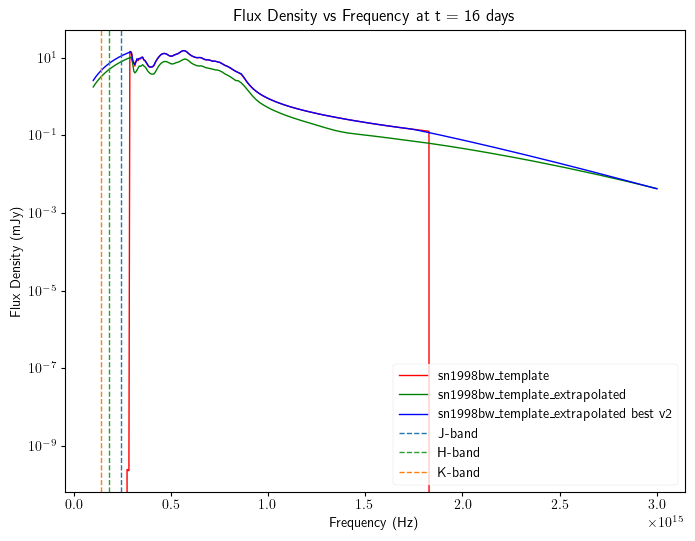

In [10]:
#plot both on the same graph to see what is happening 

#now have to let time be fixed and frequency to vary 
time = 16 #days peak time 

#frequency range (Hz) covering optical/NIR
freq_min = 1e14   # ~3 micron
freq_max = 3e15   # ~1000 Å
frequencies = np.logspace(np.log10(freq_min), np.log10(freq_max), 200)

#make frequency range for smaller for original function ? 

#TEST CASE FOR 980425
#time = 10.42 #days post explosion 
red = 0.0085
AB_mag = 14.23 + 0.21  #R band filter 
target_frequencies = 4.61700e+14 #R band Hz -- obsolete now we have frequency array and fixed time 
wavelength = np.array([6498.09000])
target_milky_way_ebv = 0.059
a_v = target_milky_way_ebv * 3.1

#original 1998bw function:
sn_1998bw1= func1(time=np.full_like(frequencies, time),
                 redshift=red, #redshift of actual event 
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#extrapolated 1998bw: 
sn_1998bw2= sn1998bw_template_with_extrapolation(time=np.full_like(frequencies, time),
                 redshift=red,
                 model_kwargs=None,
                 amplitude = 1.0,
                 output_format='flux_density', # Returns mJy
                 frequency=frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#extrapolated best 1998bw: 
sn_1998bw3= sn1998bw_template_with_extrapolation_final_v2(time=np.full_like(frequencies, time),
                 redshift=red,
                 model_kwargs=None,
                 amplitude = 1.0,
                 output_format='flux_density', # Returns mJy
                 frequency=frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#now run flux density vs frequency and have vertical lines for the J,H,K band 
plt.figure(figsize = (8,6))
plt.semilogy(frequencies,sn_1998bw1, '-r', label = 'sn1998bw_template')
plt.semilogy(frequencies,sn_1998bw2, '-g', label = 'sn1998bw_template_extrapolated')
plt.semilogy(frequencies,sn_1998bw3, '-b', label = 'sn1998bw_template_extrapolated best v2 ')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Flux Density (mJy)')
plt.title('Flux Density vs Frequency at t = {} days'.format(time))

# 5. Add vertical lines for J, H, K band central frequencies-- taken from redback 
band_centres = {
    'J': (2.42900e+14, 'tab:blue'),
    'H': (1.80500e+14, 'tab:green'),
    'K': (1.39000e+14, 'tab:orange')
}

for band, (freq,color) in band_centres.items():
    plt.axvline(freq, color = color, linestyle = '--', label = f'{band}-band')

plt.legend()
plt.show()

In [11]:
#v2 worked !!!! 
#now do checks on other GRBs 

In [12]:
#ALMOST WORKING ???!!!! perform final fix and then do test for GRB

#180728A - check -- z -- why not working ????????????????? 
target_frequencies = 3.35300e+14 #Hz
wavelength = np.array([8946.71000])

time = np.array((16.319444)) #days post explosion 
red = 0.117
AB_mag = 20.37

target_milky_way_ebv = 0.238
a_v = target_milky_way_ebv * 3.1

sn_1998bw1= sn1998bw_template_with_extrapolation_final_v2(time=time,
                 redshift=red, #redshift of actual event 
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#calculate dereddened flux density of GRB evnet: 
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

#calculate and print final ratio 
flux_ratio = dereddened_flux_event / sn_1998bw1
print("The final f_98 ratio =", flux_ratio.to_value())

#should return the same value as BASECODE_ALLGRBs 

This is the flux density of  GRB event without extinction correction: 0.02582 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.03523 mJy
The final f_98 ratio = [0.74397505]


In [13]:
#test 98bw 

AB_mag2 = 15.96 - 0.09 #B band correction 
#have to use two frequencies or two time points - pass in the same time point twice
#target_obs_times = np.array([37.46000000011176, 37.46000000011176]) #days in observer frame 
target_redshift = 0.0085
target_frequencies = 6.86300e+14 # B band 
wavelength = np.array([4371.07000]) #angstroms
target_milky_way_ebv = 0.059 


#specify a time !! 
time2 = np.array((37.46000000011176))

sn_1998bw1= sn1998bw_template_with_extrapolation_final_v2(time=time2,
                 redshift=0.0085,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )


#to get a_v from E(B-V) 
a_v = target_milky_way_ebv * 3.1 

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag2):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag2 * uu.ABmag).to(uu.mJy)

flux_density_event2 = calc_flux_density_from_ABmag(AB_mag2)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event2:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event2 = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event2) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event2[0]:.5f}")

flux_ratio = dereddened_flux_event2[0] / sn_1998bw1

print("The final f_98 ratio =", flux_ratio.to_value())

This is the flux density of  GRB event without extinction correction: 1.62930 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 2.03422 mJy
The final f_98 ratio = [1.02426116]


In [14]:
#k_s band - testing for something outside of range 
target_frequencies =  1.39000e+14 #Hz
wavelength = np.array([21590.00000])

time = np.array((16.320602)) #days post explosion 
red = 0.117
AB_mag = 21.45

target_milky_way_ebv = 0.238
a_v = target_milky_way_ebv * 3.1

sn_1998bw1= sn1998bw_template_with_extrapolation_final_v2(time=time,
                 redshift=red, #redshift of actual event 
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.88, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#calculate dereddened flux density of GRB evnet: 
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

#calculate and print final ratio 
flux_ratio = dereddened_flux_event / sn_1998bw1
print("The final f_98 ratio =", flux_ratio.to_value())


This is the flux density of  GRB event without extinction correction: 0.00955 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.01030 mJy
The final f_98 ratio = [0.33938344]
